# NASA PCoE Dataset — Exploratory Data Analysis

This notebook explores the NASA Prognostics Center of Excellence battery aging
dataset (B0005, B0006, B0007, B0018). We examine:
1. Dataset inventory and cycle structure
2. Discharge capacity fade curves
3. Voltage and temperature evolution across aging
4. SOH label computation and distribution

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing.data_loader import load_all_nasa_cells, verify_data_integrity, NASA_RATED_CAPACITY
from src.preprocessing.soh import compute_soh_for_all_cells

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

In [2]:
cells = load_all_nasa_cells("../data/raw/nasa_pcoe")
print(f"Loaded {len(cells)} cells")

for cell_id, cell_data in cells.items():
    is_valid, warnings = verify_data_integrity(cell_data)
    n_charge = sum(1 for c in cell_data["cycles"] if c["type"] == "charge")
    n_discharge = sum(1 for c in cell_data["cycles"] if c["type"] == "discharge")
    n_impedance = sum(1 for c in cell_data["cycles"] if c["type"] == "impedance")
    print(f"  {cell_id}: {n_charge} charge, {n_discharge} discharge, {n_impedance} impedance — valid={is_valid}")

Loaded 4 cells
  B0005: 170 charge, 168 discharge, 278 impedance — valid=True
  B0006: 170 charge, 168 discharge, 278 impedance — valid=True
  B0007: 170 charge, 168 discharge, 278 impedance — valid=True
  B0018: 134 charge, 132 discharge, 53 impedance — valid=True


## 2. Inventory Table

Summary statistics for each cell including cycle counts, capacity range, and EOL status.

In [3]:
records = []
for cell_id, cell_data in cells.items():
    discharge_cycles = [c for c in cell_data["cycles"] if c["type"] == "discharge"]
    capacities = [c["capacity"] for c in discharge_cycles if c["capacity"] is not None]
    records.append({
        "cell_id": cell_id,
        "total_cycles": len(cell_data["cycles"]),
        "discharge_cycles": len(discharge_cycles),
        "min_capacity_Ah": min(capacities) if capacities else None,
        "max_capacity_Ah": max(capacities) if capacities else None,
        "rated_capacity_Ah": NASA_RATED_CAPACITY,
        "capacity_fade_pct": (1 - min(capacities) / NASA_RATED_CAPACITY) * 100 if capacities else None,
        "cutoff_voltage_V": cell_data["cutoff_voltage"],
    })

inventory_df = pd.DataFrame(records)
inventory_df

,cell_id,total_cycles,discharge_cycles,min_capacity_Ah,max_capacity_Ah,rated_capacity_Ah,capacity_fade_pct,cutoff_voltage_V
0,B0005,616,168,1.287453,1.856487,2.0,35.627374,2.7
1,B0006,616,168,1.153818,2.035338,2.0,42.309083,2.5
2,B0007,616,168,1.400455,1.891052,2.0,29.977238,2.2
3,B0018,319,132,1.341051,1.855005,2.0,32.947428,2.5


## 3. Discharge Capacity Fade

Plot discharge capacity vs. cycle number for all cells. The rated capacity is 2.0 Ah;
EOL is defined as 30% fade (i.e., capacity drops below 1.4 Ah).

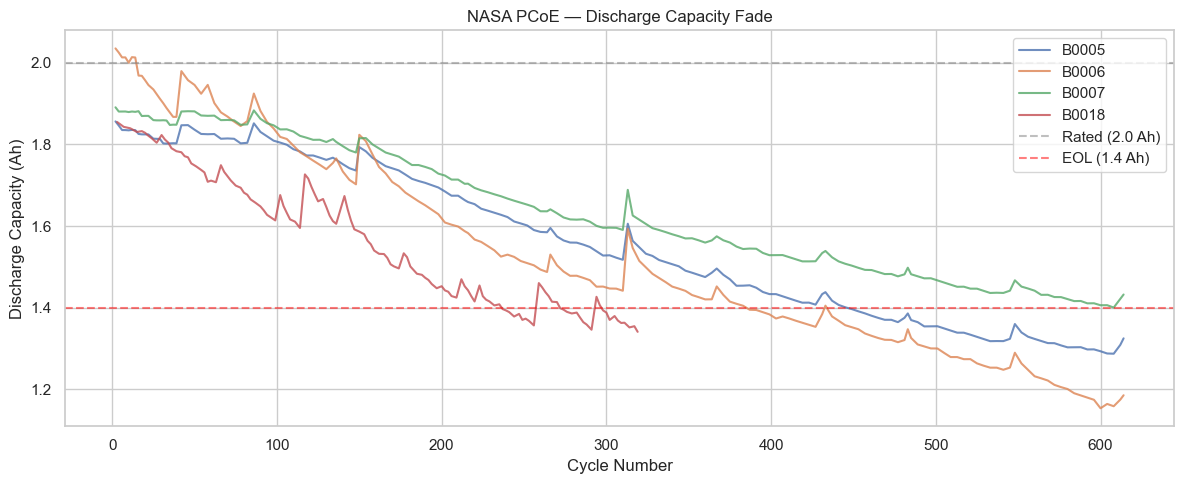

In [4]:
fig, ax = plt.subplots()
eol_capacity = NASA_RATED_CAPACITY * 0.70

for cell_id, cell_data in cells.items():
    discharge_cycles = [c for c in cell_data["cycles"] if c["type"] == "discharge"]
    cycle_nums = [c["cycle_number"] for c in discharge_cycles]
    capacities = [c["capacity"] for c in discharge_cycles]
    ax.plot(cycle_nums, capacities, label=cell_id, alpha=0.8)

ax.axhline(y=NASA_RATED_CAPACITY, color="gray", linestyle="--", alpha=0.5, label="Rated (2.0 Ah)")
ax.axhline(y=eol_capacity, color="red", linestyle="--", alpha=0.5, label=f"EOL ({eol_capacity:.1f} Ah)")
ax.set_xlabel("Cycle Number")
ax.set_ylabel("Discharge Capacity (Ah)")
ax.set_title("NASA PCoE — Discharge Capacity Fade")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Voltage Curve Evolution

Voltage discharge curves at early, mid, and late cycles to show how the
discharge profile changes with aging.

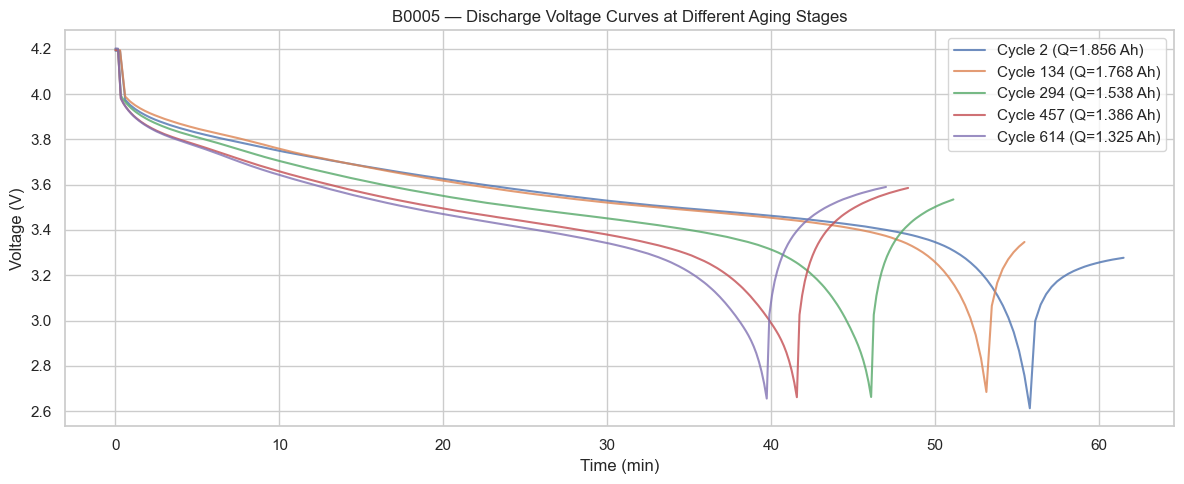

In [5]:
cell_id = "B0005"
cell_data = cells[cell_id]
discharge_cycles = [c for c in cell_data["cycles"] if c["type"] == "discharge"]

n = len(discharge_cycles)
sample_indices = [0, n // 4, n // 2, 3 * n // 4, n - 1]

fig, ax = plt.subplots()
for idx in sample_indices:
    cycle = discharge_cycles[idx]
    voltage = cycle["voltage"]
    time_min = cycle["time"] / 60.0
    label = f"Cycle {cycle['cycle_number']} (Q={cycle['capacity']:.3f} Ah)"
    ax.plot(time_min, voltage, label=label, alpha=0.8)

ax.set_xlabel("Time (min)")
ax.set_ylabel("Voltage (V)")
ax.set_title(f"{cell_id} — Discharge Voltage Curves at Different Aging Stages")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Temperature Profiles

Temperature during discharge at early, mid, and late cycles.

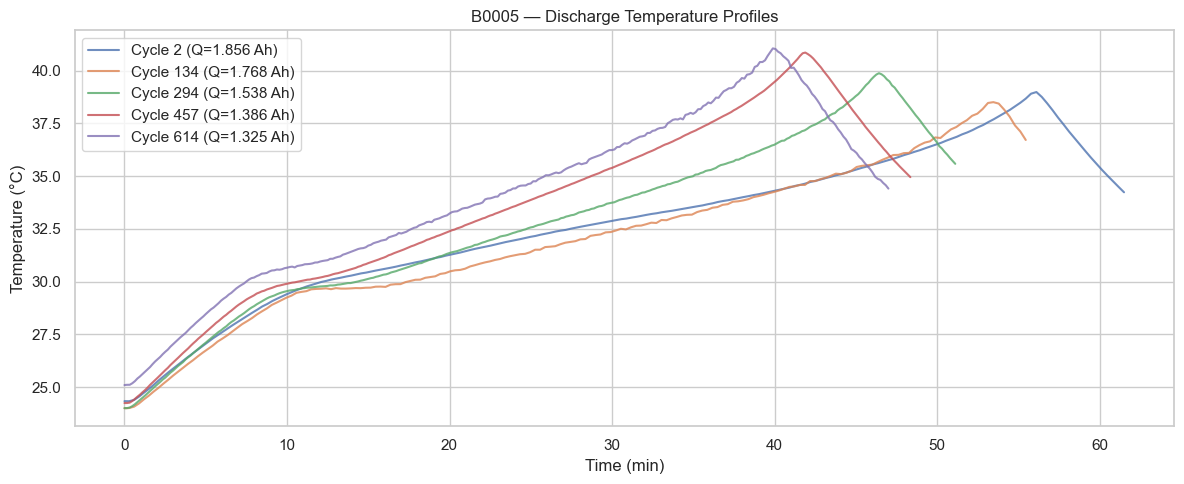

In [6]:
fig, ax = plt.subplots()
for idx in sample_indices:
    cycle = discharge_cycles[idx]
    time_min = cycle["time"] / 60.0
    label = f"Cycle {cycle['cycle_number']} (Q={cycle['capacity']:.3f} Ah)"
    ax.plot(time_min, cycle["temperature"], label=label, alpha=0.8)

ax.set_xlabel("Time (min)")
ax.set_ylabel("Temperature (°C)")
ax.set_title(f"{cell_id} — Discharge Temperature Profiles")
ax.legend()
plt.tight_layout()
plt.show()

## 6. SOH Label Distribution

Compute SOH labels and examine their distribution across cells.

SOH records: 636
       cycle_number         soh  q_discharge   q_initial
count    636.000000  636.000000   636.000000  636.000000
mean     267.077044    0.834727     1.581652    1.897716
std      177.393336    0.109527     0.198765    0.070979
min        2.000000    0.573164     1.153818    1.837896
25%      116.250000    0.752204     1.421123    1.837896
50%      248.000000    0.829354     1.559695    1.880380
75%      412.000000    0.933322     1.763486    2.013070
max      614.000000    1.000000     2.035338    2.013070


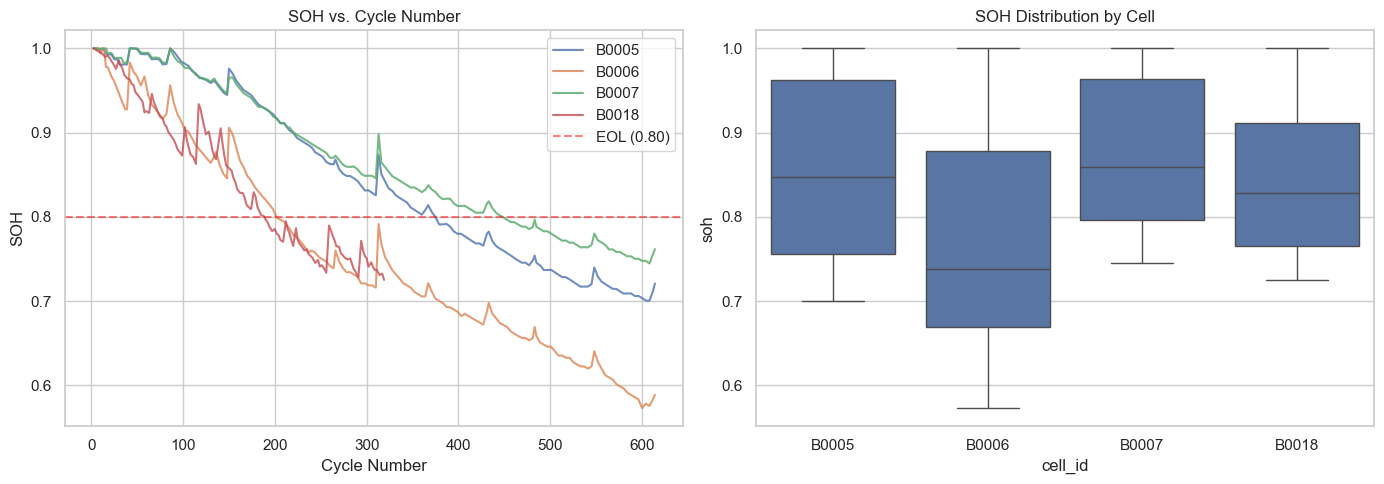

In [7]:
soh_df = compute_soh_for_all_cells(cells)
print(f"SOH records: {len(soh_df)}")
print(soh_df.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cell_id in soh_df["cell_id"].unique():
    subset = soh_df[soh_df["cell_id"] == cell_id]
    axes[0].plot(subset["cycle_number"], subset["soh"], label=cell_id, alpha=0.8)

axes[0].axhline(y=0.80, color="red", linestyle="--", alpha=0.5, label="EOL (0.80)")
axes[0].set_xlabel("Cycle Number")
axes[0].set_ylabel("SOH")
axes[0].set_title("SOH vs. Cycle Number")
axes[0].legend()

sns.boxplot(data=soh_df, x="cell_id", y="soh", ax=axes[1])
axes[1].set_title("SOH Distribution by Cell")

plt.tight_layout()
plt.show()

## 7. EIS (Electrochemical Impedance Spectroscopy)

Examine impedance measurements across aging. EIS cycles are interleaved with
charge/discharge cycles and provide internal resistance trends.

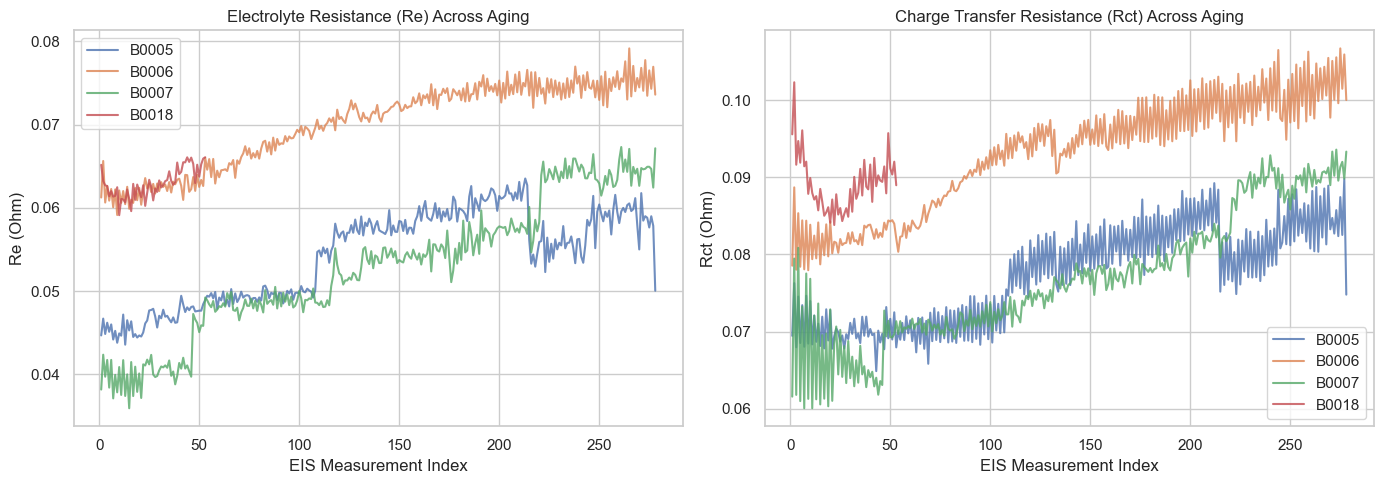

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cell_id, cell_data in cells.items():
    impedance_cycles = [c for c in cell_data["cycles"] if c["type"] == "impedance"]
    re_vals = [c["eis"]["re"] for c in impedance_cycles if c["eis"] and c["eis"]["re"] is not None]
    rct_vals = [c["eis"]["rct"] for c in impedance_cycles if c["eis"] and c["eis"]["rct"] is not None]

    axes[0].plot(range(1, len(re_vals) + 1), re_vals, label=cell_id, alpha=0.8)
    axes[1].plot(range(1, len(rct_vals) + 1), rct_vals, label=cell_id, alpha=0.8)

axes[0].set_xlabel("EIS Measurement Index")
axes[0].set_ylabel("Re (Ohm)")
axes[0].set_title("Electrolyte Resistance (Re) Across Aging")
axes[0].legend()

axes[1].set_xlabel("EIS Measurement Index")
axes[1].set_ylabel("Rct (Ohm)")
axes[1].set_title("Charge Transfer Resistance (Rct) Across Aging")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Summary & Key Observations

**Dataset structure:**
- 4 cells (B0005, B0006, B0007, B0018) with charge, discharge, and impedance cycles
- B0005/B0006/B0007 have ~616 cycles each; B0018 has ~319 (shorter experiment)
- Rated capacity: 2.0 Ah; EOL threshold: 30% fade (1.4 Ah)

**Capacity fade:**
- All cells show monotonic capacity degradation
- B0005 and B0006 reach deeper degradation (SOH ~0.57)
- B0018 ends earlier but follows similar trajectory

**Voltage/temperature:**
- Discharge voltage curves flatten and shift left as capacity fades
- Temperature profiles change with aging due to increased internal resistance

**EIS:**
- Re and Rct increase with cycling, indicating degradation
- Provides complementary features for SOH estimation